In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [195]:
pd.set_option('display.max_columns', None)

In [196]:
df = pd.read_csv('./Data/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [197]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar palm gardens,sector 83,1.8 Crore,9473.0,Super Built up area 1900(176.52 sq.m.),3,3,3+,9.0,South,1 to 5 Year Old,NaN,1900.0,NaN,NaN,0,0,0,0,0,0,55
1,flat,breez global hill view,sohna road,29.99 Lac,5403.0,Super Built up area 655(60.85 sq.m.)Carpet are...,2,2,2,6.0,North-East,0 to 1 Year Old,NaN,655.0,NaN,555.0,0,0,0,0,0,0,109
2,flat,ambience creacions,sector 22,4.78 Crore,15469.0,Super Built up area 3090(287.07 sq.m.)Built Up...,3,4,3,7.0,West,1 to 5 Year Old,NaN,3090.0,2500.0,2250.0,0,1,0,0,1,2,111
3,flat,aipl zen residences,sector 70a,1.25 Crore,9904.0,Carpet area: 1262 (117.24 sq.m.),2,2,3,19.0,NaN,undefined,NaN,NaN,NaN,1262.0,0,0,0,0,0,0,0
4,flat,sare homes,sector 92,1.18 Crore,5207.0,Carpet area: 2266 (210.52 sq.m.),4,4,3,8.0,North,1 to 5 Year Old,NaN,NaN,NaN,2266.0,0,1,0,0,0,0,108


In [198]:
df.shape

(3689, 23)

In [199]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'area', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

In [200]:
df['price'].value_counts()

price
1.25 Crore    75
1.4 Crore     57
1.2 Crore     57
1.1 Crore     56
1.5 Crore     55
              ..
82.5 Lac       1
10.8           1
88.4 Lac       1
98.1 Lac       1
2.49 Crore     1
Name: count, Length: 713, dtype: int64

In [201]:
def convert_to_crore(x):
    # Handle already numeric values or NaNs
    if pd.isna(x): return None
    
    x = str(x).lower().strip()
    if 'crore' in x:
        value = float(x.replace('crore', '').strip())
    elif 'lac' in x:
        value = float(x.replace('lac', '').strip()) * 0.01
    else:
        try:
            # This allows "10.8" to stay 10.8 instead of becoming NaN
            value = float(x)
        except ValueError:
            return None
    
    return round(value, 2)

In [202]:
df['price'] = df['price'].apply(convert_to_crore)

In [203]:
df['price']

0       1.80
1       0.30
2       4.78
3       1.25
4       1.18
        ... 
3811    7.00
3812    3.60
3813    1.08
3814    0.99
3815    1.05
Name: price, Length: 3689, dtype: float64

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\444587821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

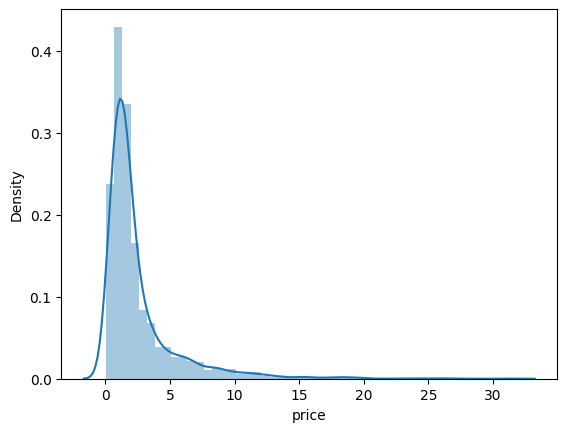

In [204]:
sns.distplot(df['price'])

<Axes: xlabel='price'>

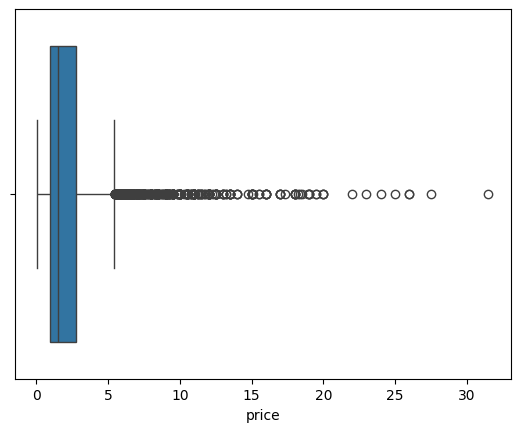

In [205]:
sns.boxplot(x=df['price'])

In [206]:
df['price'].describe()

count    3662.000000
mean        2.532936
std         2.979975
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

In [207]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [208]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
891,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,5 to 10 Year Old,9000.0,NaN,1000.0,NaN,1,1,1,1,0,2,74
2169,house,NaN,sector 43,27.50,24366.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,1 to 5 Year Old,11286.0,NaN,1254.0,NaN,1,1,0,1,1,1,42
2331,house,dlf city plots,sector 26,26.00,57206.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,0 to 1 Year Old,4545.0,NaN,505.0,NaN,1,1,0,1,1,1,138
2248,house,NaN,sector 26,26.00,82540.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,0 to 1 Year Old,3150.0,NaN,400.0,350.0,1,1,1,1,0,2,72
3533,house,suncity township,sector 54,25.00,31111.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,5 to 10 Year Old,8036.0,NaN,1000.0,NaN,1,1,1,1,0,0,0
651,house,emaar the palm springs,sector 54,24.00,600000.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,10+ Year Old,400.0,NaN,400.0,NaN,1,1,0,1,0,1,122
3670,house,NaN,sector 26,23.00,25556.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,1 to 5 Year Old,9000.0,NaN,1000.0,NaN,1,1,1,1,0,1,145
664,house,vipul tatvam villa,sector 48,22.00,26667.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,5 to 10 Year Old,8250.0,NaN,1000.0,NaN,0,1,0,0,0,0,54
790,house,NaN,sector 26,20.00,44444.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,1 to 5 Year Old,4500.0,NaN,500.0,NaN,0,1,0,1,0,2,97
2805,house,dlf city plots,sector 26,20.00,44265.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,Within 6 months,4518.0,NaN,502.0,NaN,1,1,1,1,0,1,153


C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

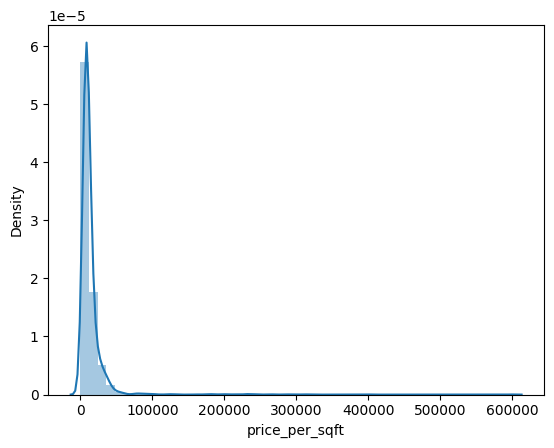

In [209]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

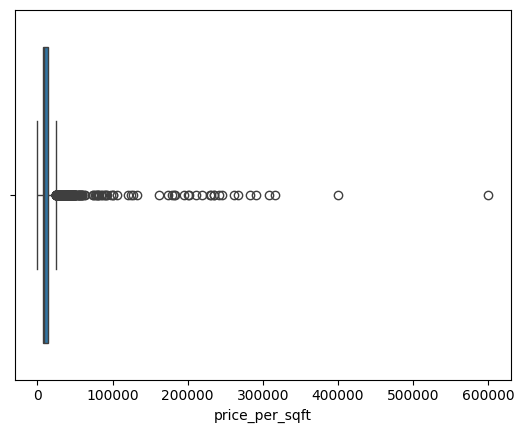

In [210]:
sns.boxplot(x=df['price_per_sqft'])

In [211]:
df['price']

0       1.80
1       0.30
2       4.78
3       1.25
4       1.18
        ... 
3811    7.00
3812    3.60
3813    1.08
3814    0.99
3815    1.05
Name: price, Length: 3689, dtype: float64

In [212]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [213]:
df['price']

0       1.80
1       0.30
2       4.78
3       1.25
4       1.18
        ... 
3811    7.00
3812    3.60
3813    1.08
3814    0.99
3815    1.05
Name: price, Length: 3689, dtype: float64

In [214]:
df['price']

0       1.80
1       0.30
2       4.78
3       1.25
4       1.18
        ... 
3811    7.00
3812    3.60
3813    1.08
3814    0.99
3815    1.05
Name: price, Length: 3689, dtype: float64

In [215]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [216]:
df['price'].describe()

count    3662.000000
mean        2.532936
std         2.979975
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

In [217]:
outliers_sqft.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
12,house,NaN,sector 55,7.49,27741.0,Plot area 300(250.84 sq.m.),12,12,3+,4.0,South-East,1 to 5 Year Old,2700.0,NaN,300.0,NaN,1,1,0,1,0,1,49
21,house,NaN,sector 25,7.60,38760.0,Plot area 215(179.77 sq.m.),9,9,3,4.0,East,1 to 5 Year Old,1961.0,NaN,215.0,NaN,1,0,1,1,0,1,84
32,house,NaN,sector 55,5.00,44444.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,0 to 1 Year Old,1125.0,NaN,115.0,100.0,0,0,0,0,1,1,44
38,house,emaar mgf marbella,sector 66,8.80,41615.0,Built Up area: 267 (223.25 sq.m.),4,4,3+,3.0,South-East,1 to 5 Year Old,2115.0,NaN,267.0,NaN,0,1,1,1,0,0,107
45,house,NaN,sector 41,11.00,33951.0,Plot area 360(301.01 sq.m.),4,4,2,3.0,East,0 to 1 Year Old,3240.0,NaN,360.0,NaN,1,1,0,1,0,1,35


In [218]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [219]:
outliers_sqft['price_per_sqft'].describe()

count      325.000000
mean     29659.867692
std      12488.696665
min       2723.000000
25%      25926.000000
50%      30556.000000
75%      36667.000000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [220]:
print(outliers_sqft[['price', 'area']].head())
print(outliers_sqft['price'].dtype)
print(outliers_sqft['area'].dtype)


    price    area
12   7.49  2700.0
21   7.60  1961.0
32   5.00  1125.0
38   8.80  2115.0
45  11.00  3240.0
float64
float64


In [221]:
outliers_sqft = outliers_sqft.dropna(subset=['price'])

In [222]:
outliers_sqft['price_per_sqft'] = (
    outliers_sqft['price'] * 10000000 / outliers_sqft['area']
).round(2)

In [223]:
outliers_sqft['price_per_sqft'].describe()

count      325.000000
mean     29659.865877
std      12488.702845
min       2723.310000
25%      25925.930000
50%      30555.560000
75%      36666.670000
max      82539.680000
Name: price_per_sqft, dtype: float64

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

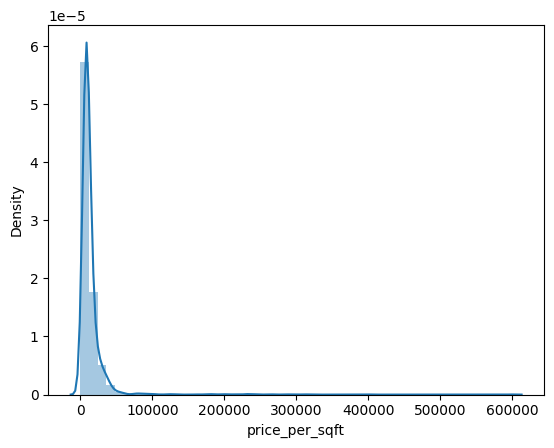

In [224]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

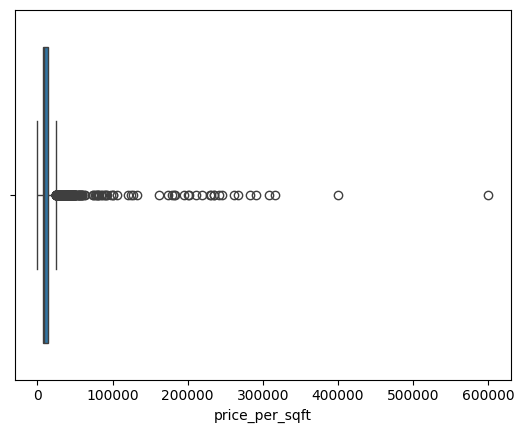

In [225]:
sns.boxplot(x=df['price_per_sqft'])

In [226]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
74,house,"bhim nagar, sector 6",sector 6,0.85,126865.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,10+ Year Old,67.0,NaN,67.0,NaN,0,0,0,1,0,0,29
206,house,NaN,sector 3,0.90,80357.0,Built Up area: 112 (10.41 sq.m.),3,3,0,2.0,NaN,undefined,112.0,NaN,112.0,NaN,0,0,0,0,0,0,0
221,house,unitech deerwood chase,sector 50,8.45,235376.0,Plot area 359(33.35 sq.m.),3,3,2,2.0,North-East,10+ Year Old,359.0,NaN,359.0,NaN,1,1,0,0,0,1,102
225,house,huda plot sector 38,sector 38,4.30,245398.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,5.0,North-West,1 to 5 Year Old,175.0,NaN,145.0,NaN,0,0,0,0,0,2,7
305,house,NaN,sector 105,0.55,98214.0,Built Up area: 56 (5.2 sq.m.),4,4,0,2.0,NaN,undefined,56.0,NaN,56.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,house,NaN,sector 5,0.75,57692.0,Built Up area: 130 (12.08 sq.m.),2,2,0,1.0,NaN,undefined,130.0,NaN,130.0,NaN,0,0,0,0,0,0,0
3480,house,NaN,sector 4,0.67,88157.0,Plot area 76(7.06 sq.m.),3,3,2,2.0,South,1 to 5 Year Old,76.0,NaN,76.0,NaN,0,0,0,0,1,0,7
3516,house,NaN,sector 24,10.00,229885.0,Carpet area: 435 (40.41 sq.m.),8,10,3+,1.0,West,undefined,435.0,NaN,NaN,435.0,0,0,0,0,0,0,0
3529,house,NaN,sector 26,14.75,51864.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,0 to 1 Year Old,2844.0,NaN,316.0,NaN,1,1,1,1,0,1,153


In [227]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

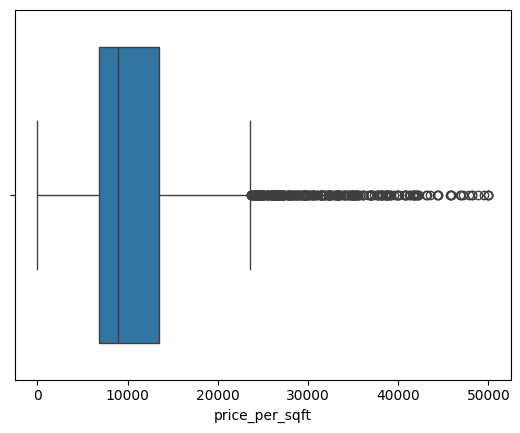

In [228]:
sns.boxplot(x=df['price_per_sqft'])

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

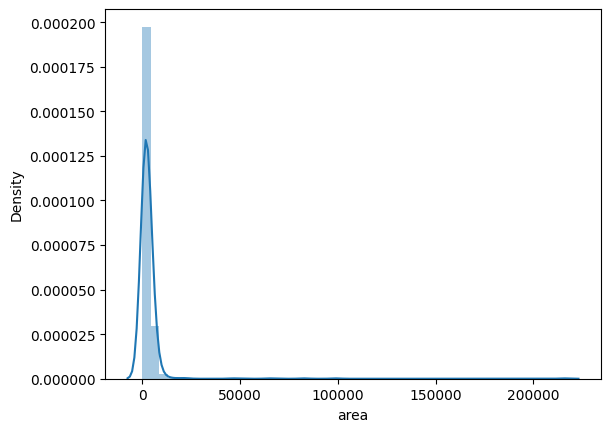

In [229]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

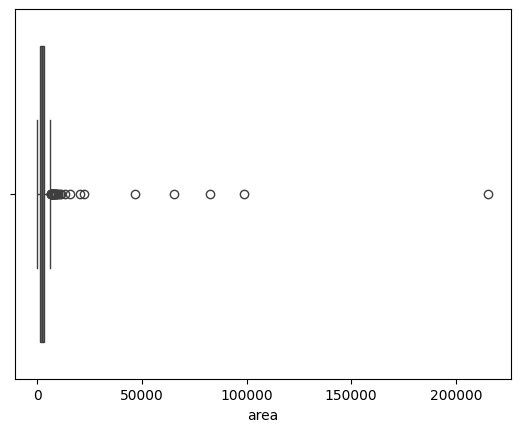

In [230]:
sns.boxplot(x=df['area'])

In [231]:
df['area'].describe()

count       783.000000
mean       3170.478927
std        9460.264767
min          96.000000
25%        1200.000000
50%        2160.000000
75%        3240.000000
max      215517.000000
Name: area, dtype: float64

In [232]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
160,house,NaN,sector 50,5.0,232.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,0 to 1 Year Old,215517.0,NaN,2.0,NaN,1,1,0,1,1,1,0


In [233]:
df = df[df['area'] < 100000]

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

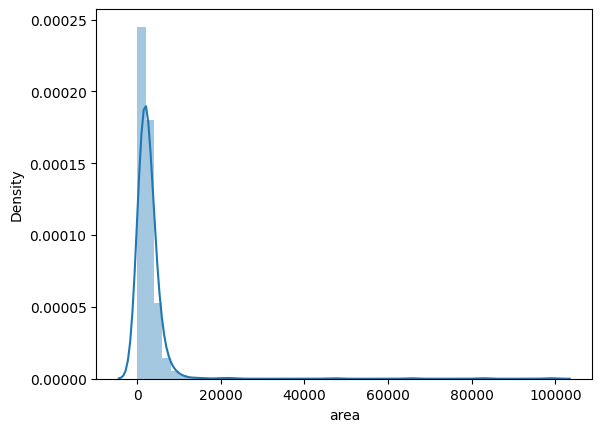

In [234]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

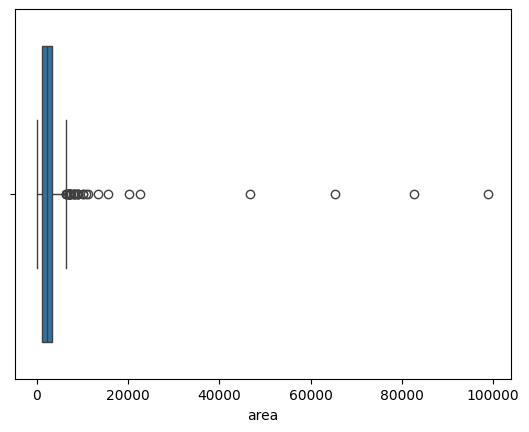

In [235]:
sns.boxplot(x=df['area'])

In [236]:
df = df.drop(df[df['area'] > 10000].index)

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

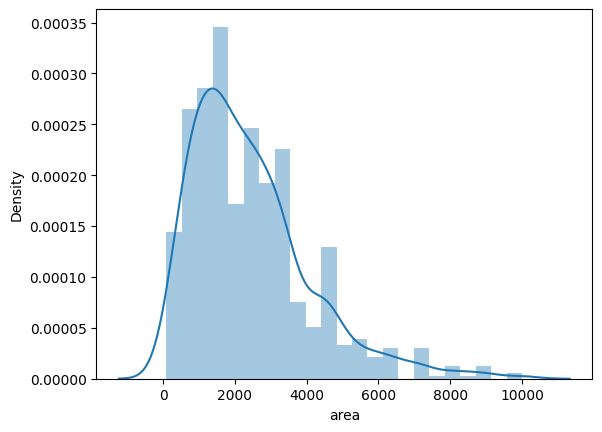

In [237]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

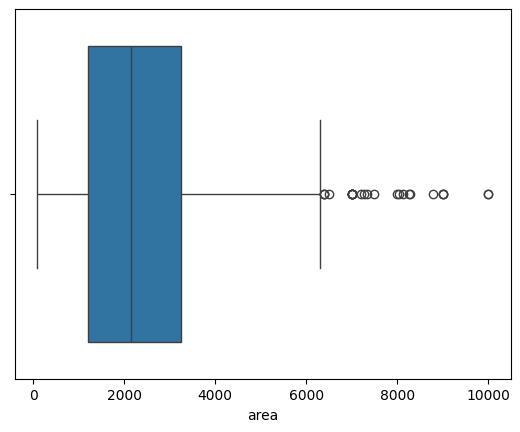

In [238]:
sns.boxplot(x=df['area'])

C:\Users\kael7\AppData\Local\Temp\ipykernel_37676\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

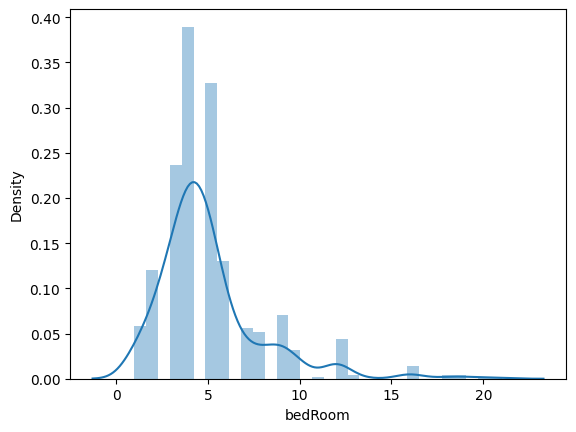

In [239]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

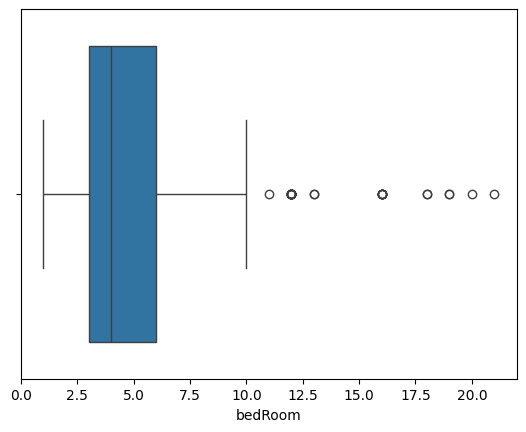

In [240]:
sns.boxplot(x=df['bedRoom'])

In [241]:
df['bedRoom'].describe()

count    772.000000
mean       5.040155
std        2.867537
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       21.000000
Name: bedRoom, dtype: float64

In [242]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
704,house,NaN,sector 54,5.00,43066.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,1 to 5 Year Old,1161.0,NaN,129.0,NaN,0,1,0,0,0,2,49
61,house,NaN,sector 43,4.50,39062.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,1 to 5 Year Old,1152.0,NaN,128.0,NaN,0,1,0,0,0,2,22
1412,house,NaN,sector 17a,3.87,5160.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,1 to 5 Year Old,7500.0,NaN,7500.0,NaN,1,0,1,0,0,0,68
2488,house,NaN,sector 17a,3.93,24214.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,1 to 5 Year Old,1623.0,NaN,1622.0,NaN,1,1,1,1,0,0,74
617,house,NaN,sector 54,5.50,38194.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,1 to 5 Year Old,1440.0,NaN,160.0,NaN,0,1,0,0,0,2,70
614,house,private house,sector 55,7.05,46906.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,1 to 5 Year Old,1503.0,NaN,167.0,NaN,0,0,0,0,1,2,57
2860,house,luxury dlf city floors,sector 26,20.00,48889.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,0 to 1 Year Old,4091.0,NaN,500.0,NaN,0,1,0,0,0,1,31
3072,house,NaN,sector 43,13.50,50000.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,1 to 5 Year Old,2700.0,NaN,300.0,NaN,1,1,0,1,1,0,41
2238,house,NaN,sector 56,12.39,45889.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,0 to 1 Year Old,2700.0,NaN,300.0,NaN,0,1,0,1,0,1,49
207,house,NaN,sector 11,4.50,25000.0,Plot area 200(167.23 sq.m.),16,16,3+,4.0,South,1 to 5 Year Old,1800.0,NaN,200.0,NaN,0,0,0,0,0,1,20


In [243]:
df = df[df['bedRoom'] <= 10]

In [244]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [245]:
df['price'].head()

11    0.7
14    0.5
21    7.6
24    1.2
32    5.0
Name: price, dtype: float64

In [247]:
df.to_csv('outlier_treated.csv',index=False)